# 13.4.预训练word2vec

我们继续实现 [13.1节](13.01_word2vec.ipynb)中定义的跳元语法模型。然后，我们将在PTB数据集上使用负采样预训练word2vec。首先，让我们通过调用`load_data_ptb`函数（定义见 13.3 节）来获得该数据集的数据迭代器和词表，该函数在 [13.3节](13.03_word_embedding_dataset.ipynb)中进行了描述。


## 13.4.1.环境配置

本节需要在昇腾 NPU 上运行 pypto 算子，因此需先完成 pypto 环境初始化。


In [2]:
import os
os.environ["TILE_FWK_DEVICE_ID"] = "0"
import warnings
warnings.filterwarnings("ignore", message="Permission mismatch")
warnings.filterwarnings("ignore", message="TASK_QUEUE_ENABLE")
warnings.filterwarnings("ignore", message="On the interactive interface")
warnings.filterwarnings("ignore", message="Cannot create tensor")
import pypto
import torch
from torch import nn
from torch.nn import functional as F
import logging
logging.getLogger("torch_npu").setLevel(logging.WARNING)
import torch_npu
logging.getLogger("matplotlib").setLevel(logging.WARNING)
import matplotlib.pyplot as plt

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"
pypto.pypto_impl.DeviceInit()

from src.pypto_ops import PyPTOBMM, PyPTOMatmul, PyPTOCosineSim, PyPTOBCELoss
from src.utils import (Timer, Animator, Accumulator, try_gpu,
                     load_data_ptb)


In [3]:
import math
import torch
from torch import nn

# load_data_ptb 数据管线已在 13.3 节收录进 src/utils.py，此处直接复用
batch_size, max_window_size, num_noise_words = 512, 5, 5
data_iter, vocab = load_data_ptb(batch_size, max_window_size,
                                 num_noise_words)


<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
import math
import torch
from torch import nn
from d2l import torch as d2l
&nbsp;
batch_size, max_window_size, num_noise_words = 512, 5, 5
data_iter, vocab = d2l.load_data_ptb(batch_size, max_window_size,
                                     num_noise_words)
    </pre>
  </div>
</details>


## 13.4.2.跳元模型

我们通过嵌入层和批量矩阵乘法实现了跳元模型。首先，让我们回顾一下嵌入层是如何工作的。

### 嵌入层

如 [9.7节](../09_pypto_modern_recurrent_neural_networks/09.07_seq2seq.ipynb)中所述，嵌入层将词元的索引映射到其特征向量。该层的权重是一个矩阵，其行数等于字典大小（`input_dim`），列数等于每个标记的向量维数（`output_dim`）。在词嵌入模型训练之后，这个权重就是我们所需要的。


In [4]:
embed = nn.Embedding(num_embeddings=20, embedding_dim=4)
print(f'Parameter embedding_weight ({embed.weight.shape}, '
      f'dtype={embed.weight.dtype})')

Parameter embedding_weight (torch.Size([20, 4]), dtype=torch.float32)


<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
embed = nn.Embedding(num_embeddings=20, embedding_dim=4)
print(f&#x27;Parameter embedding_weight ({embed.weight.shape}, &#x27;
      f&#x27;dtype={embed.weight.dtype})&#x27;)
    </pre>
  </div>
</details>


嵌入层的输入是词元（词）的索引。对于任何词元索引$i$，其向量表示可以从嵌入层中的权重矩阵的第$i$行获得。由于向量维度（`output_dim`）被设置为4，因此当小批量词元索引的形状为（2，3）时，嵌入层返回具有形状（2，3，4）的向量。


In [5]:
x = torch.tensor([[1, 2, 3], [4, 5, 6]])
embed(x)

tensor([[[ 0.2630, -0.7762, -0.9282,  0.0740],
         [-0.5742,  1.3501,  1.2763, -1.2612],
         [-0.2614, -0.6253,  0.5181,  0.2863]],

        [[ 1.0883, -1.1873,  0.4920,  0.5092],
         [ 0.8554, -1.0006, -0.6886, -0.0226],
         [-0.8636, -1.2063,  0.7206,  0.7077]]], grad_fn=<EmbeddingBackward0>)

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
x = torch.tensor([[1, 2, 3], [4, 5, 6]])
embed(x)
    </pre>
  </div>
</details>


### 定义前向传播

在前向传播中，跳元语法模型的输入包括形状为（批量大小，1）的中心词索引`center`和形状为（批量大小，`max_len`）的上下文与噪声词索引`contexts_and_negatives`，其中`max_len`在 [13.3.6节](13.03_word_embedding_dataset.ipynb)中定义。这两个变量首先通过嵌入层从词元索引转换成向量，然后它们的批量矩阵相乘（在 [10.3节](../10_pypto_attention_mechanisms/10.03_attention_scoring_functions.ipynb)中描述）返回形状为（批量大小，1，`max_len`）的输出。输出中的每个元素是中心词向量和上下文或噪声词向量的点积。


In [6]:
def skip_gram(center, contexts_and_negatives, embed_v, embed_u):
    v = embed_v(center)
    u = embed_u(contexts_and_negatives)
    pred = PyPTOBMM.apply(v, u.transpose(1, 2))
    return pred.reshape(v.shape[0], 1, -1)

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
def skip_gram(center, contexts_and_negatives, embed_v, embed_u):
    v = embed_v(center)
    u = embed_u(contexts_and_negatives)
    pred = torch.bmm(v, u.permute(0, 2, 1))
    return pred
    </pre>
  </div>
</details>


让我们为一些样例输入打印此`skip_gram`函数的输出形状。


In [7]:
skip_gram(torch.ones((2, 1), dtype=torch.long, device=device),
          torch.ones((2, 4), dtype=torch.long, device=device),
          embed.to(device), embed.to(device)).shape


torch.Size([2, 1, 4])

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
skip_gram(torch.ones((2, 1), dtype=torch.long),
          torch.ones((2, 4), dtype=torch.long), embed, embed).shape
    </pre>
  </div>
</details>


## 13.4.3.训练

在训练带负采样的跳元模型之前，我们先定义它的损失函数。

### 二元交叉熵损失

根据 [13.2.1节](13.02_approx_training.ipynb)中负采样损失函数的定义，我们将使用二元交叉熵损失。


`binary_cross_entropy_with_logits` 在 ch13 之前没有 PyPTO 实现，是**本章首次引入的融合算子**。与 [9.1.4 节](../09_pypto_modern_recurrent_neural_networks/09.01_gru.ipynb)相同的处理方式，本节**内联展示其完整 Kernel + `torch.autograd.Function` 链条**（与 `src/pypto_ops` 中实现语义等价），帮助读者看清 BCE 在 NPU 上的完整工作流：

- 前向（逐样本损失）：$out[n] = \frac{1}{L}\sum_{l} mask[n,l] \cdot \left(-\left[y\log\sigma(x) + (1-y)\log(1-\sigma(x))\right]\right)$，其中 $\sigma$ 在 (13.2.1) 中定义；
- 反向：$grad\_x[n,l] = \frac{1}{L} \cdot mask[n,l] \cdot (\sigma(x[n,l]) - y[n,l])$。


In [8]:
@pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
def bce_fwd_kernel(
    inputs: pypto.Tensor([], pypto.DT_FP32),
    targets: pypto.Tensor([], pypto.DT_FP32),
    mask: pypto.Tensor([], pypto.DT_FP32),
    out: pypto.Tensor([], pypto.DT_FP32),
    seq_len: int,
):
    cols = ((seq_len + 7) // 8) * 8
    pypto.set_vec_tile_shapes(128, cols)
    sig = pypto.sigmoid(inputs)
    log_sig = pypto.log(pypto.maximum(sig, 1e-12))
    one_minus_sig = pypto.neg(pypto.sub(sig, 1.0))
    log_1msig = pypto.log(pypto.maximum(one_minus_sig, 1e-12))
    one_minus_y = pypto.neg(pypto.sub(targets, 1.0))
    loss = pypto.neg(pypto.add(pypto.mul(targets, log_sig),
                               pypto.mul(one_minus_y, log_1msig)))
    loss = pypto.mul(loss, mask)
    s = pypto.sum(loss, 1, True)
    out.move(pypto.div(s, seq_len))

@pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
def bce_bwd_kernel(
    inputs: pypto.Tensor([], pypto.DT_FP32),
    targets: pypto.Tensor([], pypto.DT_FP32),
    mask: pypto.Tensor([], pypto.DT_FP32),
    grad_out: pypto.Tensor([], pypto.DT_FP32),
    grad_inputs: pypto.Tensor([], pypto.DT_FP32),
    seq_len: int,
):
    cols = ((seq_len + 7) // 8) * 8
    pypto.set_vec_tile_shapes(128, cols)
    sig = pypto.sigmoid(inputs)
    grad = pypto.mul(pypto.sub(sig, targets), mask)
    grad = pypto.mul(grad, pypto.div(grad_out, seq_len))
    grad_inputs.move(grad)

class PyPTOBCELossFunction(torch.autograd.Function):
    """带掩码的二元交叉熵损失（fused kernel，返回逐样本损失 (N,1)）。"""

    @staticmethod
    def forward(ctx, x, y, mask):
        seq_len = x.shape[-1]
        x_2d = x.reshape(-1, seq_len).contiguous()
        y_2d = y.reshape(-1, seq_len).contiguous()
        m_2d = mask.reshape(-1, seq_len).to(torch.float32).contiguous()
        out = torch.empty(x_2d.shape[0], 1, device=x.device, dtype=x.dtype)
        bce_fwd_kernel(x_2d, y_2d, m_2d, out, seq_len)
        ctx.save_for_backward(x_2d, y_2d, m_2d)
        ctx.seq_len = seq_len
        return out

    @staticmethod
    def backward(ctx, grad_out):
        x_2d, y_2d, m_2d = ctx.saved_tensors
        grad_x = torch.empty_like(x_2d)
        bce_bwd_kernel(x_2d, y_2d, m_2d,
                      grad_out.contiguous(), grad_x, ctx.seq_len)
        return grad_x, None, None

PyPTOBCELoss = PyPTOBCELossFunction


<details class="code-note" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠代码说明</summary>
  <div class="code-note-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <ul style="margin: 0; padding-left: 20px;">
      <li style="margin: 0 0 8px 0;"><b>带掩码的二元交叉熵损失（fused kernel，返回逐样本损失 (N,1)）</b>：语义等价 <code>torch.nn.functional.binary_cross_entropy_with_logits(inputs, target, weight=mask, reduction='none').mean(dim=1)</code>，即 <code>out[n] = (1/L) * sum_l mask[n,l] * (-[y*log(sig(x)) + (1-y)*log(1-sig(x))])</code>。</li>
      <li style="margin: 0 0 8px 0;">反向：<code>grad_x[n,l] = (1/L) * mask[n,l] * (sig(x[n,l]) - y[n,l])</code>，由 bwd kernel 完成。</li>
      <li style="margin: 0 0 8px 0;">vec 行 tile：本笔记本 seq_len（上下文+噪声词列数）≤ 60，固定 128 行向量 tile 恒安全；大 vocab 场景（如 BERT MLM）需按列数降行数，见 <code>src/pypto_ops._vec_tile_rows_for_cols</code>。</li>
    </ul>
  </div>
</details>



In [9]:
class SigmoidBCELoss(nn.Module):
    """带掩码的二元交叉熵损失（PyPTO 融合算子版，语义等价
    F.binary_cross_entropy_with_logits(reduction='none').mean(dim=1)）"""
    def __init__(self):
        super().__init__()

    def forward(self, inputs, target, mask=None):
        if mask is None:
            mask = torch.ones_like(target)
        out = PyPTOBCELoss.apply(inputs, target, mask)
        return out

loss = SigmoidBCELoss()


In [10]:
# PyPTO 融合 BCE 与 torch 参考的数值等价性验证
pred = torch.tensor([[1.1, -2.2, 3.3, -4.4]] * 2, device=device)
label = torch.tensor([[1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0]], device=device)
mask = torch.tensor([[1, 1, 1, 1], [1, 1, 0, 0]], device=device)
ref = F.binary_cross_entropy_with_logits(
    pred, label, weight=mask, reduction='none').mean(dim=1)
out = PyPTOBCELoss.apply(pred, label, mask).squeeze(1)
print(f'PyPTO BCE: {out.tolist()}')
print(f'torch 参考: {ref.tolist()}')
print(f'max diff:  {(out - ref).abs().max().item():.3e}')


PyPTO BCE: [0.9352103471755981, 0.9231046438217163]
torch 参考: [0.935210108757019, 0.9231046438217163]
max diff:  2.384e-07


<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
class SigmoidBCELoss(nn.Module):
    # 带掩码的二元交叉熵损失
    def __init__(self):
        super().__init__()
    def forward(self, inputs, target, mask=None):
        out = nn.functional.binary_cross_entropy_with_logits(
            inputs, target, weight=mask, reduction=&quot;none&quot;)
        return out.mean(dim=1)
&nbsp;
loss = SigmoidBCELoss()
    </pre>
  </div>
</details>


回想一下我们在 [13.3.6节](13.03_word_embedding_dataset.ipynb)中对掩码变量和标签变量的描述。下面计算给定变量的二进制交叉熵损失。


In [11]:
pred = torch.tensor([[1.1, -2.2, 3.3, -4.4]] * 2, device=device)
label = torch.tensor([[1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0]], device=device)
mask = torch.tensor([[1, 1, 1, 1], [1, 1, 0, 0]], device=device)
loss(pred, label, mask) * mask.shape[1] / mask.sum(axis=1)


tensor([[0.9352, 1.8704],
        [0.9231, 1.8462]], device='npu:0')

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
pred = torch.tensor([[1.1, -2.2, 3.3, -4.4]] * 2)
label = torch.tensor([[1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0]])
mask = torch.tensor([[1, 1, 1, 1], [1, 1, 0, 0]])
loss(pred, label, mask) * mask.shape[1] / mask.sum(axis=1)
    </pre>
  </div>
</details>


下面显示了如何使用二元交叉熵损失中的Sigmoid激活函数（以较低效率的方式）计算上述结果。我们可以将这两个输出视为两个规范化的损失，在非掩码预测上进行平均。


In [12]:
def sigmd(x):
    return -math.log(1 / (1 + math.exp(-x)))

print(f'{(sigmd(1.1) + sigmd(2.2) + sigmd(-3.3) + sigmd(4.4)) / 4:.4f}')
print(f'{(sigmd(-1.1) + sigmd(-2.2)) / 2:.4f}')

0.9352
1.8462


<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
def sigmd(x):
    return -math.log(1 / (1 + math.exp(-x)))
&nbsp;
print(f&#x27;{(sigmd(1.1) + sigmd(2.2) + sigmd(-3.3) + sigmd(4.4)) / 4:.4f}&#x27;)
print(f&#x27;{(sigmd(-1.1) + sigmd(-2.2)) / 2:.4f}&#x27;)
    </pre>
  </div>
</details>


### 初始化模型参数

我们定义了两个嵌入层，将词表中的所有单词分别作为中心词和上下文词使用。字向量维度`embed_size`被设置为100。


In [13]:
embed_size = 100
net = nn.Sequential(nn.Embedding(num_embeddings=len(vocab),
                                 embedding_dim=embed_size),
                    nn.Embedding(num_embeddings=len(vocab),
                                 embedding_dim=embed_size))

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
embed_size = 100
net = nn.Sequential(nn.Embedding(num_embeddings=len(vocab),
                                 embedding_dim=embed_size),
                    nn.Embedding(num_embeddings=len(vocab),
                                 embedding_dim=embed_size))
    </pre>
  </div>
</details>


### 定义训练阶段代码

训练阶段代码实现定义如下。由于填充的存在，损失函数的计算与以前的训练函数略有不同。


In [14]:
def train(net, data_iter, lr, num_epochs, device=try_gpu()):
    def init_weights(m):
        if type(m) == nn.Embedding:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    net = net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    animator = Animator(xlabel='epoch', ylabel='loss',
                        xlim=[1, num_epochs])
    # 规范化的损失之和，规范化的损失数
    metric = Accumulator(2)
    for epoch in range(num_epochs):
        timer, num_batches = Timer(), len(data_iter)
        for i, batch in enumerate(data_iter):
            optimizer.zero_grad()
            center, context_negative, mask, label = [
                data.to(device) for data in batch]

            pred = skip_gram(center, context_negative, net[0], net[1])
            l = (loss(pred.reshape(label.shape).float(), label.float(), mask)
                     / mask.sum(axis=1) * mask.shape[1])
            l.sum().backward()
            optimizer.step()
            metric.add(l.sum(), l.numel())
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[1],))
    print(f'loss {metric[0] / metric[1]:.3f}, '
          f'{metric[1] / timer.stop():.1f} tokens/sec on {str(device)}')

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
def train(net, data_iter, lr, num_epochs, device=d2l.try_gpu()):
    def init_weights(m):
        if type(m) == nn.Embedding:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    net = net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    animator = d2l.Animator(xlabel=&#x27;epoch&#x27;, ylabel=&#x27;loss&#x27;,
                            xlim=[1, num_epochs])
    # 规范化的损失之和，规范化的损失数
    metric = d2l.Accumulator(2)
    for epoch in range(num_epochs):
        timer, num_batches = d2l.Timer(), len(data_iter)
        for i, batch in enumerate(data_iter):
            optimizer.zero_grad()
            center, context_negative, mask, label = [
                data.to(device) for data in batch]
&nbsp;
            pred = skip_gram(center, context_negative, net[0], net[1])
            l = (loss(pred.reshape(label.shape).float(), label.float(), mask)
                     / mask.sum(axis=1) * mask.shape[1])
            l.sum().backward()
            optimizer.step()
            metric.add(l.sum(), l.numel())
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[1],))
    print(f&#x27;loss {metric[0] / metric[1]:.3f}, &#x27;
          f&#x27;{metric[1] / timer.stop():.1f} tokens/sec on {str(device)}&#x27;)
    </pre>
  </div>
</details>


现在，我们可以使用负采样来训练跳元模型。


loss 0.574, 59653441.6 tokens/sec on npu:0


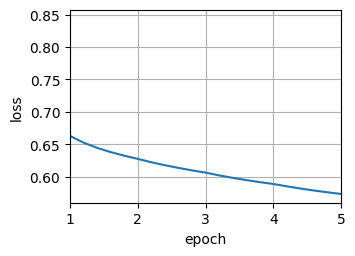

In [15]:
lr, num_epochs = 0.002, 5
train(net, data_iter, lr, num_epochs, device=device)

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
lr, num_epochs = 0.002, 5
train(net, data_iter, lr, num_epochs)
    </pre>
  </div>
</details>


## 13.4.4.应用词嵌入

在训练word2vec模型之后，我们可以使用训练好模型中词向量的余弦相似度来从词表中找到与输入单词语义最相似的单词。


In [16]:
def get_similar_tokens(query_token, k, embed, W_norm_sq):
    W = embed.weight.data
    x = W[vocab[query_token]]
    # 计算余弦相似性。增加1e-9以获得数值稳定性
    cos = PyPTOCosineSim.apply(W, x.reshape(-1, 1), W_norm_sq).squeeze(1)
    topk = torch.topk(cos, k=k+1)[1].cpu().numpy().astype('int32')
    for i in topk[1:]:  # 删除输入词
        print(f'cosine sim={float(cos[i]):.3f}: {vocab.to_tokens(i)}')

W = net[0].weight.data
W_norm_sq = torch.sum(W * W, dim=1, keepdim=True)  # 行范数平方一次预计算
get_similar_tokens('chip', 3, net[0], W_norm_sq)


cosine sim=0.783: microprocessor
cosine sim=0.733: intel
cosine sim=0.724: chips


<details class="code-note" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠代码说明</summary>
  <div class="code-note-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <ul style="margin: 0; padding-left: 20px;">
      <li style="margin: 0 0 8px 0;">余弦相似度 = W·x / (‖W‖·‖x‖)，由 <code>PyPTOCosineSim</code> 单个 kernel 完成（算子完整实现见 <a href="./13.07_similarity_analogy.ipynb">13.7 节</a>）：kernel 内做 W·x（cube matmul）并乘 <code>rsqrt(W_norm_sq·x_norm_sq + 1e-9)</code>（vec 归一化）；W 与 W_norm_sq 常驻 NPU，查询零搬运、零重复计算。</li>
    </ul>
  </div>
</details>
<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
def get_similar_tokens(query_token, k, embed):
    W = embed.weight.data
    x = W[vocab[query_token]]
    # 计算余弦相似性。增加1e-9以获得数值稳定性
    cos = torch.mv(W, x) / torch.sqrt(torch.sum(W * W, dim=1) *
                                      torch.sum(x * x) + 1e-9)
    topk = torch.topk(cos, k=k+1)[1].cpu().numpy().astype(&#x27;int32&#x27;)
    for i in topk[1:]:  # 删除输入词
        print(f&#x27;cosine sim={float(cos[i]):.3f}: {vocab.to_tokens(i)}&#x27;)
&nbsp;
get_similar_tokens(&#x27;chip&#x27;, 3, net[0])
    </pre>
  </div>
</details>


## 13.4.5.小结

* 我们可以使用嵌入层和二元交叉熵损失来训练带负采样的跳元模型。
* 词嵌入的应用包括基于词向量的余弦相似度为给定词找到语义相似的词。



## 13.4.6.练习

1. 使用训练好的模型，找出其他输入词在语义上相似的词。您能通过调优超参数来改进结果吗？
1. 当训练语料库很大时，在更新模型参数时，我们经常对当前小批量的*中心词*进行上下文词和噪声词的采样。换言之，同一中心词在不同的训练迭代轮数可以有不同的上下文词或噪声词。这种方法的好处是什么？尝试实现这种训练方法。


参考答案详见 [answers/13.04_word2vec_pretraining_reference_answer](./answers/13.04_word2vec_pretraining_reference_answer.ipynb)。

### 13.4.6.1.参考答案（PyPTO）


In [17]:
!cat answers/txt/13.04_word2vec_pretraining_reference_answer_pypto.txt

### 13.4.6.2.参考答案（PyTorch）


In [18]:
!cat answers/txt/13.04_word2vec_pretraining_reference_answer_pytorch.txt